In [11]:
# Cell 1 - Imports

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [12]:
# Cell 2 - Paths and settings

BASE_DIR = Path("/Users/tonytony/Final Project")
RAW_DIR = BASE_DIR / "Data" / "Raw"
CLEAN_DIR = BASE_DIR / "Data" / "Cleaned"

PANEL_PATH = CLEAN_DIR / "panel_with_event_dummies_and_extra_drivers.csv"
GDP_PATH = RAW_DIR / "gdp.csv"
POP_PATH = RAW_DIR / "population.csv"
LIFE_PATH = RAW_DIR / "life_expectancy.csv"
INFLATION_PATH = RAW_DIR / "inflation.csv"
UNEMPLOYMENT_PATH = RAW_DIR / "unemployment.csv"
internet_candidates = [
    RAW_DIR / "individuals_using_the_Internet.csv",
    RAW_DIR / "individuals_using_ the_Internet.csv"
]

INTERNET_PATH = None
for candidate in internet_candidates:
    if candidate.exists():
        INTERNET_PATH = candidate
        break

if INTERNET_PATH is None:
    raise FileNotFoundError("Internet dataset file was not found in Data/Raw.")
META_PATH = RAW_DIR / "world_bank_country_metadata.csv"

COUNTRY_CODE_INPUT = "VNM"
TARGET_YEAR_INPUT = 2040

POP_FORECAST_MODEL = "LogHolt"
LIFE_FORECAST_MODEL = "Holt"
INFLATION_FORECAST_MODEL = "Naive"
UNEMPLOYMENT_FORECAST_MODEL = "Naive"
INTERNET_FORECAST_MODEL = "Holt"

print("Panel path:", PANEL_PATH)
print("Country:", COUNTRY_CODE_INPUT)
print("Target year:", TARGET_YEAR_INPUT)

Panel path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Country: VNM
Target year: 2040


In [13]:
# Cell 3 - Helper functions for World Bank raw data

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    return df


def to_long(df, value_name):
    year_cols = [col for col in df.columns if str(col).isdigit()]
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=year_cols,
        var_name="year",
        value_name=value_name
    )
    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce")
    return long_df


def load_metadata():
    meta = pd.read_csv(META_PATH)

    meta = meta.rename(
        columns={
            "Country Code": "country_code",
            "World Bank Name": "country_name",
            "World Bank Region": "wb_region"
        }
    )

    meta = meta[["country_code", "country_name", "wb_region"]].copy()
    meta["country_code"] = meta["country_code"].astype(str).str.strip()
    meta["country_name"] = meta["country_name"].astype(str).str.strip()
    meta["wb_region"] = meta["wb_region"].astype(str).str.strip()

    meta = meta[meta["wb_region"].notna()].copy()
    meta = meta[meta["wb_region"] != ""].copy()
    meta = meta[meta["wb_region"].str.lower() != "aggregates"].copy()

    return meta


def add_region_info(long_df, value_col):
    meta = load_metadata()

    out = long_df.rename(
        columns={
            "Country Name": "country_name",
            "Country Code": "country_code"
        }
    ).copy()

    out["country_code"] = out["country_code"].astype(str).str.strip()
    out["country_name"] = out["country_name"].astype(str).str.strip()

    out = out.merge(meta, on="country_code", how="left", suffixes=("", "_meta"))

    if "country_name_meta" in out.columns:
        out["country_name"] = out["country_name_meta"].fillna(out["country_name"])
        out = out.drop(columns=["country_name_meta"], errors="ignore")

    out = out[["country_name", "country_code", "wb_region", "year", value_col]].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")

    out = out.dropna(subset=["country_code", "year"])
    out["year"] = out["year"].astype(int)

    return out

In [14]:
# Cell 4 - Load raw long series

gdp_long = add_region_info(
    to_long(load_wdi(GDP_PATH), "gdp_per_capita_usd"),
    "gdp_per_capita_usd"
)

pop_long = add_region_info(
    to_long(load_wdi(POP_PATH), "population_total"),
    "population_total"
)

life_long = add_region_info(
    to_long(load_wdi(LIFE_PATH), "life_expectancy_years"),
    "life_expectancy_years"
)

inflation_long = add_region_info(
    to_long(load_wdi(INFLATION_PATH), "inflation_pct"),
    "inflation_pct"
)

unemployment_long = add_region_info(
    to_long(load_wdi(UNEMPLOYMENT_PATH), "unemployment_pct"),
    "unemployment_pct"
)

internet_long = add_region_info(
    to_long(load_wdi(INTERNET_PATH), "internet_users_pct"),
    "internet_users_pct"
)

gdp_long = gdp_long[gdp_long["gdp_per_capita_usd"].notna()].copy()
pop_long = pop_long[pop_long["population_total"].notna()].copy()
life_long = life_long[life_long["life_expectancy_years"].notna()].copy()
inflation_long = inflation_long[inflation_long["inflation_pct"].notna()].copy()
unemployment_long = unemployment_long[unemployment_long["unemployment_pct"].notna()].copy()
internet_long = internet_long[internet_long["internet_users_pct"].notna()].copy()

print("GDP long:", gdp_long.shape)
print("Population long:", pop_long.shape)
print("Life long:", life_long.shape)
print("Inflation long:", inflation_long.shape)
print("Unemployment long:", unemployment_long.shape)
print("Internet long:", internet_long.shape)

GDP long: (14561, 5)
Population long: (17195, 5)
Life long: (16926, 5)
Inflation long: (9066, 5)
Unemployment long: (8211, 5)
Internet long: (6917, 5)


In [15]:
# Cell 5 - Load panel data for XGBoost Model 2

model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year"
]

panel_df = pd.read_csv(PANEL_PATH, usecols=model_cols)

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year"
]

for col in numeric_cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

panel_df["country_name"] = panel_df["country_name"].astype(str)
panel_df["country_code"] = panel_df["country_code"].astype(str)
panel_df["wb_region"] = panel_df["wb_region"].astype(str)

model_df = panel_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)

print("Model 2 panel shape:", model_df.shape)
print("Feature year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))
display(model_df.head())

Model 2 panel shape: (4722, 13)
Feature year range: 1991 - 2022


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean
43,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2005,254.1842,58.2470,"24,404,567.0000",5.5381,17.0103,5.6139,12.6863,7.8780,1.2241
44,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2006,274.2186,58.5530,"25,424,094.0000",5.6139,17.0512,5.9302,6.7846,7.8970,2.1071
45,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2007,376.2232,58.9560,"25,909,852.0000",5.9302,17.0701,5.9447,8.6806,7.8410,1.9000
46,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2008,381.7332,59.7080,"26,482,622.0000",5.9447,17.0920,6.1138,26.4187,7.8790,1.8400
47,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2009,452.0537,60.2480,"27,466,101.0000",6.1138,17.1285,6.3290,-2.8285,7.8080,3.5500


In [16]:
# Cell 6 - Train XGBoost Model 2

feature_cols = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean"
]

target_col = "target_log_gdp_next_year"

train_core_df = model_df[model_df["year"] < 2016].copy()
valid_df = model_df[(model_df["year"] >= 2016) & (model_df["year"] <= 2017)].copy()

if train_core_df.empty or valid_df.empty:
    raise ValueError("Train/validation split is empty. Check panel data first.")

dtrain_core = xgb.DMatrix(
    train_core_df[feature_cols],
    label=train_core_df[target_col],
    feature_names=feature_cols
)

dvalid = xgb.DMatrix(
    valid_df[feature_cols],
    label=valid_df[target_col],
    feature_names=feature_cols
)

params = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "max_depth": 4,
    "eta": 0.05,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 5,
    "seed": 42
}

evals_result = {}

tuned_model_2 = xgb.train(
    params=params,
    dtrain=dtrain_core,
    num_boost_round=800,
    evals=[(dtrain_core, "train"), (dvalid, "valid")],
    early_stopping_rounds=40,
    evals_result=evals_result,
    verbose_eval=False
)

best_nrounds = tuned_model_2.best_iteration + 1
print("Best boosting rounds:", best_nrounds)

dfit_full = xgb.DMatrix(
    model_df[feature_cols],
    label=model_df[target_col],
    feature_names=feature_cols
)

final_model_2 = xgb.train(
    params=params,
    dtrain=dfit_full,
    num_boost_round=best_nrounds,
    evals=[(dfit_full, "fit_full")],
    verbose_eval=False
)

print("Final Model 2 trained.")

Best boosting rounds: 128
Final Model 2 trained.


In [17]:
# Cell 7 - Helper functions for future feature paths

def apply_bounds(values, lower_clip=None, upper_clip=None):
    arr = np.asarray(values, dtype=float)

    if lower_clip is not None:
        arr = np.maximum(arr, lower_clip)

    if upper_clip is not None:
        arr = np.minimum(arr, upper_clip)

    return arr


def forecast_country_series(series, model_name, forecast_horizon):
    series = pd.Series(series).dropna().astype(float)
    series = series[~series.index.duplicated(keep="last")]

    if forecast_horizon <= 0:
        return np.array([])

    if len(series) < 3:
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Naive":
        last_val = float(series.iloc[-1])
        return np.repeat(last_val, forecast_horizon)

    if model_name == "Holt":
        fitted = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)

        fc = fitted.forecast(forecast_horizon)
        return np.asarray(fc, dtype=float)

    if model_name == "LogHolt":
        safe_series = series.clip(lower=1)
        log_series = np.log(safe_series)

        fitted = ExponentialSmoothing(
            log_series,
            trend="add",
            seasonal=None,
            initialization_method="estimated"
        ).fit(optimized=True)

        fc = fitted.forecast(forecast_horizon)
        return np.exp(np.asarray(fc, dtype=float))

    raise ValueError(f"Unsupported model_name: {model_name}")


def build_actual_lookup(long_df, country_code, value_col, lower_clip=None, upper_clip=None):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()
    country_df[value_col] = apply_bounds(country_df[value_col].values, lower_clip=lower_clip, upper_clip=upper_clip)

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    return actual_lookup, last_actual_year, country_df


def build_forecast_lookup(long_df, country_code, value_col, forecast_to_year, model_name, lower_clip=None, upper_clip=None):
    country_df = long_df[long_df["country_code"] == country_code].copy().sort_values("year")

    if country_df.empty:
        raise ValueError(f"No data found for country_code={country_code} in {value_col}")

    country_df[value_col] = pd.to_numeric(country_df[value_col], errors="coerce")
    country_df = country_df[country_df[value_col].notna()].copy()
    country_df[value_col] = apply_bounds(country_df[value_col].values, lower_clip=lower_clip, upper_clip=upper_clip)

    actual_lookup = dict(zip(country_df["year"], country_df[value_col]))
    last_actual_year = int(country_df["year"].max())

    if forecast_to_year <= last_actual_year:
        return actual_lookup, last_actual_year, country_df

    horizon = forecast_to_year - last_actual_year
    series = country_df.set_index("year")[value_col]

    future_values = forecast_country_series(
        series=series,
        model_name=model_name,
        forecast_horizon=horizon
    )

    future_values = apply_bounds(future_values, lower_clip=lower_clip, upper_clip=upper_clip)

    future_lookup = {
        year: value
        for year, value in zip(range(last_actual_year + 1, forecast_to_year + 1), future_values)
    }

    full_lookup = {**actual_lookup, **future_lookup}
    return full_lookup, last_actual_year, country_df

In [18]:
# Cell 8 - Build actual and future lookups

country_code_input = COUNTRY_CODE_INPUT.upper()

gdp_lookup, gdp_last_year, gdp_country_df = build_actual_lookup(
    gdp_long,
    country_code=country_code_input,
    value_col="gdp_per_capita_usd"
)

pop_lookup, pop_last_year, pop_country_df = build_forecast_lookup(
    pop_long,
    country_code=country_code_input,
    value_col="population_total",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=POP_FORECAST_MODEL,
    lower_clip=1
)

life_lookup, life_last_year, life_country_df = build_forecast_lookup(
    life_long,
    country_code=country_code_input,
    value_col="life_expectancy_years",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=LIFE_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=120
)

inflation_lookup, inflation_last_year, inflation_country_df = build_forecast_lookup(
    inflation_long,
    country_code=country_code_input,
    value_col="inflation_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=INFLATION_FORECAST_MODEL
)

unemployment_lookup, unemployment_last_year, unemployment_country_df = build_forecast_lookup(
    unemployment_long,
    country_code=country_code_input,
    value_col="unemployment_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=UNEMPLOYMENT_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=100
)

internet_lookup, internet_last_year, internet_country_df = build_forecast_lookup(
    internet_long,
    country_code=country_code_input,
    value_col="internet_users_pct",
    forecast_to_year=TARGET_YEAR_INPUT - 1,
    model_name=INTERNET_FORECAST_MODEL,
    lower_clip=0,
    upper_clip=100
)

country_name_value = gdp_country_df["country_name"].dropna().iloc[-1]
region_value = gdp_country_df["wb_region"].dropna().iloc[-1] if gdp_country_df["wb_region"].notna().any() else "Unknown"

print("Country:", country_name_value, f"({country_code_input})")
print("Region:", region_value)
print("Latest actual GDP year:", gdp_last_year)
print("Target forecast year:", TARGET_YEAR_INPUT)

print("GDP lookup years:", min(gdp_lookup.keys()), "-", max(gdp_lookup.keys()))
print("Population lookup years:", min(pop_lookup.keys()), "-", max(pop_lookup.keys()))
print("Life lookup years:", min(life_lookup.keys()), "-", max(life_lookup.keys()))
print("Inflation lookup years:", min(inflation_lookup.keys()), "-", max(inflation_lookup.keys()))
print("Unemployment lookup years:", min(unemployment_lookup.keys()), "-", max(unemployment_lookup.keys()))
print("Internet lookup years:", min(internet_lookup.keys()), "-", max(internet_lookup.keys()))

Country: Viet Nam (VNM)
Region: East Asia & Pacific
Latest actual GDP year: 2024
Target forecast year: 2040
GDP lookup years: 1985 - 2024
Population lookup years: 1960 - 2039
Life lookup years: 1960 - 2039
Inflation lookup years: 1996 - 2039
Unemployment lookup years: 1991 - 2039
Internet lookup years: 1990 - 2039


In [19]:
# Cell 9 - Recursive GDP forecast using XGBoost Model 2

def recursive_gdp_forecast_model_2(
    booster,
    country_code,
    country_name,
    region_name,
    target_year,
    gdp_lookup,
    pop_lookup,
    life_lookup,
    inflation_lookup,
    unemployment_lookup,
    internet_lookup
):
    actual_gdp_years = sorted(gdp_lookup.keys())
    latest_actual_gdp_year = max(actual_gdp_years)

    if target_year <= latest_actual_gdp_year:
        raise ValueError(
            f"Target year must be greater than the latest actual GDP year. "
            f"Latest actual GDP year for {country_code} is {latest_actual_gdp_year}, "
            f"but you entered {target_year}."
        )

    current_gdp = float(gdp_lookup[latest_actual_gdp_year])

    forecast_rows = []

    for forecast_year in range(latest_actual_gdp_year + 1, target_year + 1):
        feature_year = forecast_year - 1

        if feature_year not in pop_lookup:
            raise ValueError(f"Missing population value for feature year {feature_year}")
        if feature_year not in life_lookup:
            raise ValueError(f"Missing life expectancy value for feature year {feature_year}")
        if feature_year not in inflation_lookup:
            raise ValueError(f"Missing inflation value for feature year {feature_year}")
        if feature_year not in unemployment_lookup:
            raise ValueError(f"Missing unemployment value for feature year {feature_year}")
        if feature_year not in internet_lookup:
            raise ValueError(f"Missing internet value for feature year {feature_year}")

        pop_value = float(pop_lookup[feature_year])
        life_value = float(life_lookup[feature_year])
        inflation_value = float(inflation_lookup[feature_year])
        unemployment_value = float(unemployment_lookup[feature_year])
        internet_value = float(internet_lookup[feature_year])

        feature_frame = pd.DataFrame(
            {
                "log_gdp_per_capita": [np.log(max(current_gdp, 1e-9))],
                "log_population_total": [np.log(max(pop_value, 1e-9))],
                "life_expectancy_years": [life_value],
                "inflation_pct_clean": [inflation_value],
                "unemployment_pct_clean": [unemployment_value],
                "internet_users_pct_clean": [internet_value]
            }
        )

        dmatrix = xgb.DMatrix(feature_frame[feature_cols], feature_names=feature_cols)
        pred_log_gdp = float(booster.predict(dmatrix)[0])
        pred_gdp = float(np.exp(pred_log_gdp))

        forecast_rows.append(
            {
                "country_name": country_name,
                "country_code": country_code,
                "wb_region": region_name,
                "latest_actual_gdp_year": latest_actual_gdp_year,
                "feature_year_used": feature_year,
                "target_year": forecast_year,
                "gdp_input_used": current_gdp,
                "population_used": pop_value,
                "life_expectancy_used": life_value,
                "inflation_used": inflation_value,
                "unemployment_used": unemployment_value,
                "internet_users_used": internet_value,
                "predicted_log_gdp_per_capita": pred_log_gdp,
                "predicted_gdp_per_capita_usd": pred_gdp,
                "population_model": POP_FORECAST_MODEL,
                "life_model": LIFE_FORECAST_MODEL,
                "inflation_model": INFLATION_FORECAST_MODEL,
                "unemployment_model": UNEMPLOYMENT_FORECAST_MODEL,
                "internet_model": INTERNET_FORECAST_MODEL,
                "gdp_model": "XGBoost Model 2 Recursive"
            }
        )

        current_gdp = pred_gdp

    return pd.DataFrame(forecast_rows)

In [20]:
# Cell 10 - Run forecast

forecast_model_2_df = recursive_gdp_forecast_model_2(
    booster=final_model_2,
    country_code=country_code_input,
    country_name=country_name_value,
    region_name=region_value,
    target_year=TARGET_YEAR_INPUT,
    gdp_lookup=gdp_lookup,
    pop_lookup=pop_lookup,
    life_lookup=life_lookup,
    inflation_lookup=inflation_lookup,
    unemployment_lookup=unemployment_lookup,
    internet_lookup=internet_lookup
)

display(forecast_model_2_df.head(10))
display(forecast_model_2_df.tail(10))

,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model
0,Viet Nam,VNM,East Asia & Pacific,2024,2024,2025,"4,717.2903","100,987,686.0000",74.8784,3.6211,1.6020,84.1500,8.5488,"5,160.4620",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
1,Viet Nam,VNM,East Asia & Pacific,2024,2025,2026,"5,160.4620","101,627,204.3534",75.1413,3.6211,1.5230,87.7962,8.6160,"5,519.4977",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
2,Viet Nam,VNM,East Asia & Pacific,2024,2026,2027,"5,519.4977","102,270,772.5438",75.4042,3.6211,1.5230,91.4425,8.6516,"5,719.3114",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
3,Viet Nam,VNM,East Asia & Pacific,2024,2027,2028,"5,719.3114","102,918,416.2179",75.6671,3.6211,1.5230,95.0887,8.7520,"6,323.4418",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
4,Viet Nam,VNM,East Asia & Pacific,2024,2028,2029,"6,323.4418","103,570,161.1842",75.9300,3.6211,1.5230,98.7350,8.7517,"6,321.2591",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
5,Viet Nam,VNM,East Asia & Pacific,2024,2029,2030,"6,321.2591","104,226,033.4148",76.1929,3.6211,1.5230,100.0000,8.7429,"6,266.2076",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"6,266.2076","104,886,059.0461",76.4558,3.6211,1.5230,100.0000,8.7653,"6,407.8055",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"6,407.8055","105,550,264.3802",76.7187,3.6211,1.5230,100.0000,8.8457,"6,944.7302",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"6,944.7302","106,218,675.8855",76.9816,3.6211,1.5230,100.0000,8.9160,"7,450.1674",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"7,450.1674","106,891,320.1982",77.2445,3.6211,1.5230,100.0000,9.0371,"8,409.7301",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive


,country_name,country_code,wb_region,latest_actual_gdp_year,feature_year_used,target_year,gdp_input_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,predicted_log_gdp_per_capita,predicted_gdp_per_capita_usd,population_model,life_model,inflation_model,unemployment_model,internet_model,gdp_model
6,Viet Nam,VNM,East Asia & Pacific,2024,2030,2031,"6,266.2076","104,886,059.0461",76.4558,3.6211,1.5230,100.0000,8.7653,"6,407.8055",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
7,Viet Nam,VNM,East Asia & Pacific,2024,2031,2032,"6,407.8055","105,550,264.3802",76.7187,3.6211,1.5230,100.0000,8.8457,"6,944.7302",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
8,Viet Nam,VNM,East Asia & Pacific,2024,2032,2033,"6,944.7302","106,218,675.8855",76.9816,3.6211,1.5230,100.0000,8.9160,"7,450.1674",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
9,Viet Nam,VNM,East Asia & Pacific,2024,2033,2034,"7,450.1674","106,891,320.1982",77.2445,3.6211,1.5230,100.0000,9.0371,"8,409.7301",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
10,Viet Nam,VNM,East Asia & Pacific,2024,2034,2035,"8,409.7301","107,568,224.1231",77.5074,3.6211,1.5230,100.0000,9.0869,"8,838.9267",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
11,Viet Nam,VNM,East Asia & Pacific,2024,2035,2036,"8,838.9267","108,249,414.6348",77.7703,3.6211,1.5230,100.0000,9.1967,"9,864.9467",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
12,Viet Nam,VNM,East Asia & Pacific,2024,2036,2037,"9,864.9467","108,934,918.8788",78.0332,3.6211,1.5230,100.0000,9.2977,"10,913.2958",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
13,Viet Nam,VNM,East Asia & Pacific,2024,2037,2038,"10,913.2958","109,624,764.1722",78.2961,3.6211,1.5230,100.0000,9.3867,"11,928.6772",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
14,Viet Nam,VNM,East Asia & Pacific,2024,2038,2039,"11,928.6772","110,318,978.0055",78.5590,3.6211,1.5230,100.0000,9.5092,"13,483.5391",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive
15,Viet Nam,VNM,East Asia & Pacific,2024,2039,2040,"13,483.5391","111,017,588.0429",78.8219,3.6211,1.5230,100.0000,9.6727,"15,878.1157",LogHolt,Holt,Naive,Naive,Holt,XGBoost Model 2 Recursive


In [21]:
# Cell 11 - Clean output table

output_df = forecast_model_2_df[
    [
        "target_year",
        "population_used",
        "life_expectancy_used",
        "inflation_used",
        "unemployment_used",
        "internet_users_used",
        "predicted_gdp_per_capita_usd"
    ]
].copy()

output_df["population_used"] = output_df["population_used"].round(0).astype("int64")
output_df["life_expectancy_used"] = output_df["life_expectancy_used"].round(2)
output_df["inflation_used"] = output_df["inflation_used"].round(2)
output_df["unemployment_used"] = output_df["unemployment_used"].round(2)
output_df["internet_users_used"] = output_df["internet_users_used"].round(2)
output_df["predicted_gdp_per_capita_usd"] = output_df["predicted_gdp_per_capita_usd"].round(2)

display(output_df)

,target_year,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used,predicted_gdp_per_capita_usd
0,2025,100987686,74.8800,3.6200,1.6000,84.1500,"5,160.4600"
1,2026,101627204,75.1400,3.6200,1.5200,87.8000,"5,519.5000"
2,2027,102270773,75.4000,3.6200,1.5200,91.4400,"5,719.3100"
3,2028,102918416,75.6700,3.6200,1.5200,95.0900,"6,323.4400"
4,2029,103570161,75.9300,3.6200,1.5200,98.7300,"6,321.2600"
5,2030,104226033,76.1900,3.6200,1.5200,100.0000,"6,266.2100"
6,2031,104886059,76.4600,3.6200,1.5200,100.0000,"6,407.8100"
7,2032,105550264,76.7200,3.6200,1.5200,100.0000,"6,944.7300"
8,2033,106218676,76.9800,3.6200,1.5200,100.0000,"7,450.1700"
9,2034,106891320,77.2400,3.6200,1.5200,100.0000,"8,409.7300"


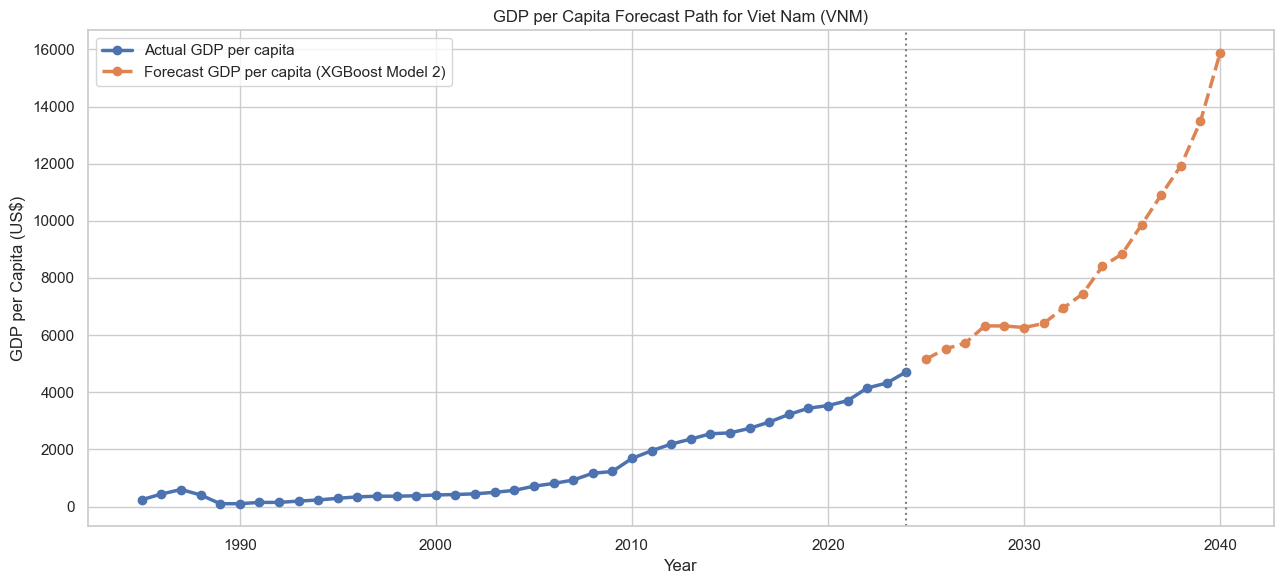

In [22]:
# Cell 12 - Plot GDP forecast path

historical_plot_df = gdp_country_df[["year", "gdp_per_capita_usd"]].copy()
historical_plot_df = historical_plot_df.rename(columns={"year": "target_year"})
historical_plot_df["series_type"] = "Actual GDP per capita"

future_plot_df = forecast_model_2_df[["target_year", "predicted_gdp_per_capita_usd"]].copy()
future_plot_df = future_plot_df.rename(columns={"predicted_gdp_per_capita_usd": "gdp_per_capita_usd"})
future_plot_df["series_type"] = "Forecast GDP per capita"

plot_df = pd.concat([historical_plot_df, future_plot_df], ignore_index=True)

plt.figure(figsize=(13, 6))

actual_df = plot_df[plot_df["series_type"] == "Actual GDP per capita"]
forecast_df = plot_df[plot_df["series_type"] == "Forecast GDP per capita"]

plt.plot(
    actual_df["target_year"],
    actual_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    label="Actual GDP per capita"
)

plt.plot(
    forecast_df["target_year"],
    forecast_df["gdp_per_capita_usd"],
    marker="o",
    linewidth=2.5,
    linestyle="--",
    label="Forecast GDP per capita (XGBoost Model 2)"
)

plt.axvline(x=int(actual_df["target_year"].max()), color="gray", linestyle=":", linewidth=1.5)
plt.title(f"GDP per Capita Forecast Path for {country_name_value} ({country_code_input})")
plt.xlabel("Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Cell 13 - Optional: inspect future driver paths

driver_preview_df = forecast_model_2_df[
    [
        "feature_year_used",
        "population_used",
        "life_expectancy_used",
        "inflation_used",
        "unemployment_used",
        "internet_users_used"
    ]
].copy()

display(driver_preview_df.head(15))
display(driver_preview_df.tail(15))

,feature_year_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used
0,2024,"100,987,686.0000",74.8784,3.6211,1.6020,84.1500
1,2025,"101,627,204.3534",75.1413,3.6211,1.5230,87.7962
2,2026,"102,270,772.5438",75.4042,3.6211,1.5230,91.4425
3,2027,"102,918,416.2179",75.6671,3.6211,1.5230,95.0887
4,2028,"103,570,161.1842",75.9300,3.6211,1.5230,98.7350
5,2029,"104,226,033.4148",76.1929,3.6211,1.5230,100.0000
6,2030,"104,886,059.0461",76.4558,3.6211,1.5230,100.0000
7,2031,"105,550,264.3802",76.7187,3.6211,1.5230,100.0000
8,2032,"106,218,675.8855",76.9816,3.6211,1.5230,100.0000
9,2033,"106,891,320.1982",77.2445,3.6211,1.5230,100.0000


,feature_year_used,population_used,life_expectancy_used,inflation_used,unemployment_used,internet_users_used
1,2025,"101,627,204.3534",75.1413,3.6211,1.5230,87.7962
2,2026,"102,270,772.5438",75.4042,3.6211,1.5230,91.4425
3,2027,"102,918,416.2179",75.6671,3.6211,1.5230,95.0887
4,2028,"103,570,161.1842",75.9300,3.6211,1.5230,98.7350
5,2029,"104,226,033.4148",76.1929,3.6211,1.5230,100.0000
6,2030,"104,886,059.0461",76.4558,3.6211,1.5230,100.0000
7,2031,"105,550,264.3802",76.7187,3.6211,1.5230,100.0000
8,2032,"106,218,675.8855",76.9816,3.6211,1.5230,100.0000
9,2033,"106,891,320.1982",77.2445,3.6211,1.5230,100.0000
10,2034,"107,568,224.1231",77.5074,3.6211,1.5230,100.0000


In [24]:
# Cell 14 - Save output

save_path = CLEAN_DIR / f"gdp_xgboost_model_2_future_forecast_{country_code_input}_{TARGET_YEAR_INPUT}.csv"
forecast_model_2_df.to_csv(save_path, index=False)

print("Saved to:", save_path)

Saved to: /Users/tonytony/Final Project/Data/Cleaned/gdp_xgboost_model_2_future_forecast_VNM_2040.csv


In [25]:
# Cell 15 - Quick summary

latest_forecast_row = forecast_model_2_df.iloc[-1]

print("=== MODEL 2 FUTURE FORECAST SUMMARY ===")
print("Country:", latest_forecast_row["country_name"], f"({latest_forecast_row['country_code']})")
print("Region:", latest_forecast_row["wb_region"])
print("Target year:", int(latest_forecast_row["target_year"]))
print("Predicted GDP per capita (US$):", round(float(latest_forecast_row["predicted_gdp_per_capita_usd"]), 2))
print("Population model used:", latest_forecast_row["population_model"])
print("Life model used:", latest_forecast_row["life_model"])
print("Inflation model used:", latest_forecast_row["inflation_model"])
print("Unemployment model used:", latest_forecast_row["unemployment_model"])
print("Internet model used:", latest_forecast_row["internet_model"])
print("GDP model used:", latest_forecast_row["gdp_model"])

=== MODEL 2 FUTURE FORECAST SUMMARY ===
Country: Viet Nam (VNM)
Region: East Asia & Pacific
Target year: 2040
Predicted GDP per capita (US$): 15878.12
Population model used: LogHolt
Life model used: Holt
Inflation model used: Naive
Unemployment model used: Naive
Internet model used: Holt
GDP model used: XGBoost Model 2 Recursive
